# Étape 99 (1/3) — indicateurs et intervalles de confiance

**Attention à ce que ça mesure.** Les indicateurs et intervalles de confiance de ce notebook décrivent
NOTRE méthode d'estimation du BKT (étapes 04-06), PAS le "vrai" BKT national. Personne n'observe le
vrai BKT national - il n'existe pas de vérité terrain à laquelle comparer notre estimation. Un
intervalle de confiance ici répond à : "si on avait eu un échantillon différent de communes actives,
à quel point notre taux rogné (et le BKT_ext qui en découle) aurait-il pu varier ?" - une incertitude
D'ÉCHANTILLONNAGE propre à la méthode, pas une mesure d'écart à une réalité inobservable. Voir le
README de ce dossier.

## 0. Configuration — [`pipeline.py`](pipeline.py)

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
pd.set_option("display.width", 160)

DOSSIER_BKT = RACINE / "data" / "donnees_valides" / "bkt"

## 1. Résultat déjà préparé (ou à préparer) — [`pipeline.py`](pipeline.py)

In [2]:
if not (DOSSIER_BKT / "indicateurs.csv").exists() or not (DOSSIER_BKT / "ic_standard.csv").exists():
    print("Pas encore calculé - lancement de pipeline.py (le bootstrap prend quelques minutes).")
    import runpy
    runpy.run_path(str(ICI / "pipeline.py"), run_name="__main__")
else:
    print(f"déjà calculé : {DOSSIER_BKT}")

déjà calculé : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\bkt


## 2. Indicateurs de base — [`indicateurs.py`](indicateurs.py)

Population, capteurs (standard ET panel équilibré), réseau, débits, BKT standard et « mini ».

In [3]:
indicateurs = pd.read_csv(DOSSIER_BKT / "indicateurs.csv")
indicateurs.round(3)

,annee,population,n_capteurs_actifs,n_capteurs_panel,lineaire_fob_km,somme_debits,bkt_obs_Mdkm,bkt_ext_Mdkm,bkt_mini_obs_Mdkm,bkt_mini_ext_Mdkm
0,2019,68229198.0,672,489,86667.026,7.360819e+07,2.386,6.143,2.117,6.368
1,2020,68388307.0,795,489,96458.298,1.124806e+08,3.386,7.475,2.163,7.072
2,2021,68620565.0,1070,489,104305.050,1.647446e+08,4.944,9.717,2.570,8.722
3,2022,69009539.0,1227,489,111397.901,2.072098e+08,5.401,10.929,2.946,10.219
4,2023,69342437.0,1395,489,119164.292,2.327460e+08,5.972,11.153,3.035,10.781
5,2024,69342437.0,1402,489,126642.293,2.307074e+08,6.303,11.314,3.227,11.735
6,2025,69342437.0,1291,489,134594.132,2.256780e+08,6.571,12.445,3.440,12.830


## 3. BKT standard vs BKT « mini » (panel équilibré)

Le panel équilibré ne garde que les capteurs présents TOUTES les années sans interruption - un test de
robustesse : si la croissance mesurée venait surtout d'un échantillon de capteurs qui grossit, le BKT
mini (échantillon FIXE) croîtrait beaucoup moins que le BKT standard.

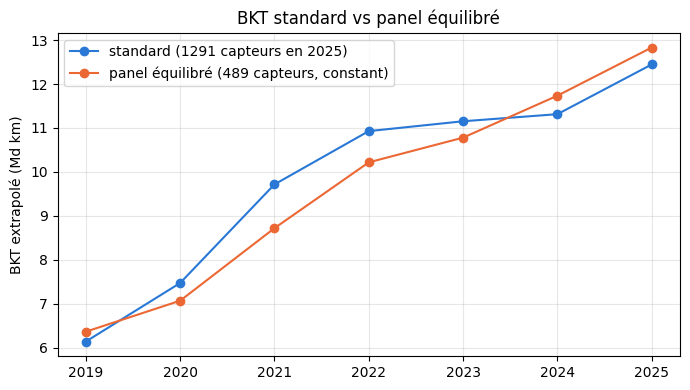

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(indicateurs["annee"], indicateurs["bkt_ext_Mdkm"], marker="o", label=f"standard ({indicateurs['n_capteurs_actifs'].iloc[-1]} capteurs en {indicateurs['annee'].iloc[-1]})", color="#2a78d6")
ax.plot(indicateurs["annee"], indicateurs["bkt_mini_ext_Mdkm"], marker="o", label=f"panel équilibré ({indicateurs['n_capteurs_panel'].iloc[0]} capteurs, constant)", color="#eb6834")
ax.set_ylabel("BKT extrapolé (Md km)")
ax.set_title("BKT standard vs panel équilibré")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Intervalles de confiance bootstrap (3000 tirages) — [`intervalle_confiance.py`](intervalle_confiance.py)

In [5]:
ic_standard = pd.read_csv(DOSSIER_BKT / "ic_standard.csv")
ic_standard.round(3)

,annee,mediane_bootstrap,ic_bas_95,ic_haut_95,largeur_relative_pct
0,2019,6.178,5.208,7.392,35.341
1,2020,7.574,7.023,8.664,21.657
2,2021,9.794,9.181,10.713,15.647
3,2022,10.920,10.266,11.738,13.478
4,2023,11.157,10.602,11.704,9.879
5,2024,11.348,10.819,11.957,10.028
6,2025,12.504,11.836,13.329,11.944


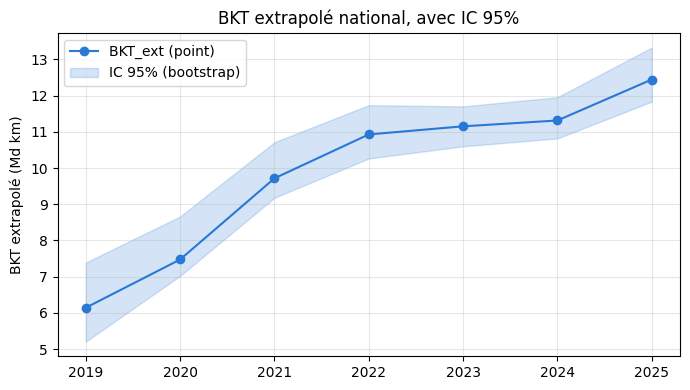

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(indicateurs["annee"], indicateurs["bkt_ext_Mdkm"], marker="o", color="#2a78d6", label="BKT_ext (point)")
ax.fill_between(ic_standard["annee"], ic_standard["ic_bas_95"], ic_standard["ic_haut_95"], alpha=0.2, color="#2a78d6", label="IC 95% (bootstrap)")
ax.set_ylabel("BKT extrapolé (Md km)")
ax.set_title("BKT extrapolé national, avec IC 95%")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. La croissance est-elle statistiquement significative ? — bootstrap apparié

In [7]:
test_croissance = pd.read_csv(DOSSIER_BKT / "test_croissance.csv")
test_croissance.round(4)

,transition,ratio_median,ic_bas_95,ic_haut_95,p_value_pas_de_croissance,significatif_5pct
0,2019 -> 2020,1.1946,1.1040,1.2818,0.0,oui
1,2020 -> 2021,1.3588,1.2954,1.4402,0.0,oui
2,2021 -> 2022,1.1381,1.0975,1.1793,0.0,oui
3,2022 -> 2023,1.0556,1.0346,1.0741,0.0,oui
4,2023 -> 2024,1.0410,1.0213,1.0650,0.0,oui
5,2024 -> 2025,1.0851,1.0625,1.1079,0.0,oui
6,2019 -> 2025 (cumulé),2.1020,1.9090,2.2963,0.0,oui


## 6. Vérifications de cohérence

Deux contrôles internes : la largeur relative de l'intervalle de confiance doit globalement DIMINUER
quand le nombre de capteurs actifs augmente (plus l'échantillon est grand, plus l'estimation bootstrap
est précise) ; et le point estimé (`bkt_ext_Mdkm`) doit toujours tomber À L'INTÉRIEUR de son propre
intervalle de confiance à 95 % (sinon la médiane bootstrap et le point n'estiment pas la même chose).

In [8]:
comp = indicateurs.merge(ic_standard, on="annee")
dans_ic = comp["bkt_ext_Mdkm"].between(comp["ic_bas_95"], comp["ic_haut_95"])
print("bkt_ext_Mdkm dans son propre IC 95%, chaque année :")
print(dans_ic.to_string())
assert dans_ic.all(), "le point estimé tombe hors de son intervalle de confiance - incohérence"

correlation = comp["n_capteurs_actifs"].corr(comp["largeur_relative_pct"])
print(f"\ncorrélation (n capteurs actifs, largeur relative de l'IC) : {correlation:.2f} (attendu : négative)")
assert correlation < 0, "la largeur de l'IC ne diminue pas avec la taille de l'échantillon - suspect"
print("OK.")

bkt_ext_Mdkm dans son propre IC 95%, chaque année :
0    True
1    True
2    True
3    True
4    True
5    True
6    True

corrélation (n capteurs actifs, largeur relative de l'IC) : -0.94 (attendu : négative)
OK.


## Bilan

Les indicateurs, le panel équilibré et les intervalles de confiance bootstrap passent leurs contrôles
de cohérence interne : le point estimé tombe toujours dans son propre IC 95 %, et la précision de
l'estimation s'améliore avec la taille de l'échantillon de capteurs, comme attendu d'un bootstrap bien
construit. **Rappel : ces intervalles quantifient l'incertitude de NOTRE méthode d'extrapolation
(échantillonnage des communes actives), pas un écart à un "vrai" BKT national - qui n'est observable
par personne.**